In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# XGBoost library
from xgboost import XGBClassifier

In [ ]:
from google.colab import files

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/data mining for cybersecurity - data/Live GPS Spoofing and Jamming/UAV_Attack_Dataset_SUBSET.csv'
data = pd.read_csv(file_path)

In [ ]:
selected_features = ['control[0]',
    'control[1]',
    'control[2]',
    'control[3]',
    'vel_m_s',
    'vel_n_m_s',
   'vel_e_m_s',
   'vel_d_m_s',
   'gps_hvel[0]_var',
  'gps_hvel[0]_inn',
  'gps_hvel[1]_inn',
  'gps_vvel_inn',
  'gps_hpos[0]_inn',
  'gps_hpos[1]_inn']
data_subset = data[selected_features]

In [ ]:
X = data_subset
y = data['class']

In [ ]:
class_mapping = {
    'benign flight': 0,
    'gps jamming': 1,
    'gps spoofing': 2
    }

In [ ]:
y = y.map(class_mapping)

In [ ]:
# FEATURE ENGINEERING

print("FEATURE ENGINEERING")

# Control Signal Statistics
control_columns = [c for c in X.columns if 'control' in c]
if len(control_columns) > 1:
    X['control_std'] = X[control_columns].std(axis=1)

# GPS Variance Sum
variance_columns = [c for c in X.columns if '_var' in c]
if len(variance_columns) > 1:
    X['gps_var_sum'] = X[variance_columns].sum(axis=1)

# GPS Innovation Sum
innovation_columns = [c for c in X.columns if '_inn' in c]
if len(innovation_columns) > 1:
    X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)
    print("Created: gps_inn_sum (Sum of Absolute Innovations)")

print(f"\n Total features after engineering: {X.shape[1]}")

FEATURE ENGINEERING
Created: gps_inn_sum (Sum of Absolute Innovations)

 Total features after engineering: 16


/tmp/ipython-input-505/2959810596.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['control_std'] = X[control_columns].std(axis=1)
/tmp/ipython-input-505/2959810596.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)


In [ ]:
print("Renaming columns to remove special characters for XGBoost...")
X.columns = [col.replace('[', '_').replace(']', '').replace('<', '_') for col in X.columns]
# --------------------------------------------------

print(f"Total number of features: {X.shape[1]}")
print(f"New feature names: {list(X.columns)}")

Renaming columns to remove special characters for XGBoost...
Total number of features: 16
New feature names: ['control_0', 'control_1', 'control_2', 'control_3', 'vel_m_s', 'vel_n_m_s', 'vel_e_m_s', 'vel_d_m_s', 'gps_hvel_0_var', 'gps_hvel_0_inn', 'gps_hvel_1_inn', 'gps_vvel_inn', 'gps_hpos_0_inn', 'gps_hpos_1_inn', 'control_std', 'gps_inn_sum']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

In [ ]:
print("Searching for best parameters using Grid Search...")
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

Searching for best parameters using Grid Search...


In [ ]:
# Start Training
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:59:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1.0]},
             verbose=1)

In [ ]:
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")


Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.9715


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [ ]:
class_labels = ["benign flight", "gps jamming", "gps spoofing"]

print("\n--- XGBoost Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_labels))


--- XGBoost Results ---
Accuracy: 0.9735537190082645

Classification Report:
                precision    recall  f1-score   support

benign flight       0.97      0.99      0.98       493
  gps jamming       0.97      0.96      0.97       444
 gps spoofing       0.97      0.97      0.97       273

     accuracy                           0.97      1210
    macro avg       0.97      0.97      0.97      1210
 weighted avg       0.97      0.97      0.97      1210



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

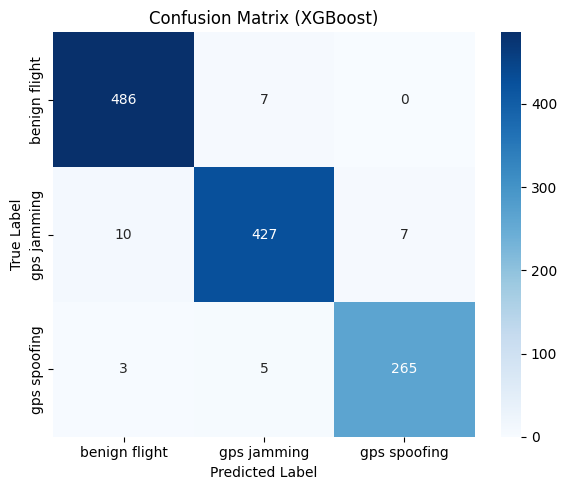

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (XGBoost)")
plt.tight_layout()
plt.savefig('confusion_matrix.pdf', format='pdf', bbox_inches='tight')

files.download('confusion_matrix.pdf')

plt.show()

In [ ]:
# FEATURE IMPORTANCE ANALYSIS

# Create DataFrame with feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Display top features
print("FEATURE IMPORTANCE")

for rank, (_, row) in enumerate(feature_importance.iterrows(), 1):
    # Create visual bar using characters
    bar = '█' * int(row['Importance'] * 40)
    print(f"{rank:2d}. {row['Feature']:<25} {row['Importance']:.4f} {bar}")

FEATURE IMPORTANCE
 1. control_3                 0.3421 █████████████
 2. gps_hvel_0_var            0.0877 ███
 3. gps_vvel_inn              0.0780 ███
 4. control_2                 0.0643 ██
 5. control_std               0.0616 ██
 6. gps_hpos_0_inn            0.0539 ██
 7. vel_d_m_s                 0.0481 █
 8. gps_hpos_1_inn            0.0468 █
 9. vel_n_m_s                 0.0419 █
10. vel_m_s                   0.0348 █
11. gps_inn_sum               0.0304 █
12. vel_e_m_s                 0.0303 █
13. gps_hvel_1_inn            0.0238 
14. control_1                 0.0223 
15. gps_hvel_0_inn            0.0207 
16. control_0                 0.0134 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

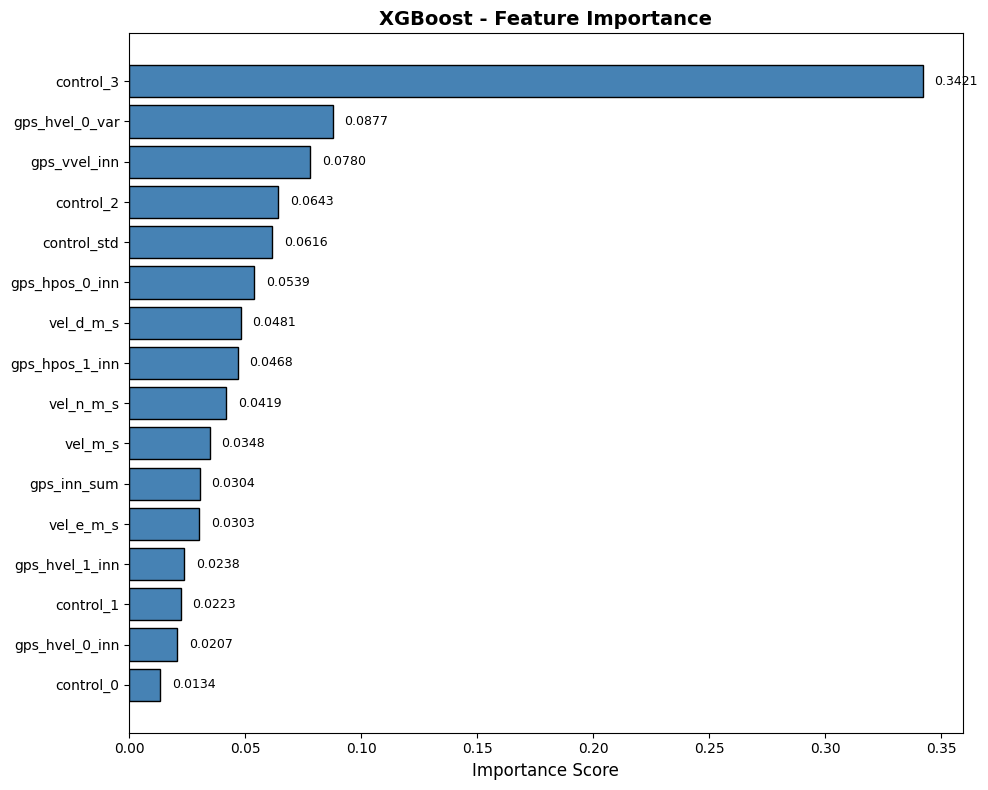

In [ ]:
# FEATURE IMPORTANCE VISUALIZATION

# Create horizontal bar chart
plt.figure(figsize=(10, 8))

# Plot bars
bars = plt.barh(range(len(feature_importance)),
                feature_importance['Importance'],
                color='steelblue', edgecolor='black')

# Set y-axis labels
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])

# Labels and title
plt.xlabel('Importance Score', fontsize=12)
plt.title('XGBoost - Feature Importance', fontsize=14, fontweight='bold')

# Invert y-axis so most important is at top
plt.gca().invert_yaxis()

# Add value labels
for bar, value in zip(bars, feature_importance['Importance']):
    plt.text(value + 0.005, bar.get_y() + bar.get_height()/2,
             f'{value:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.pdf', format='pdf', dpi=150, bbox_inches='tight')
try:
    files.download('feature_importance.pdf')
except:
    pass
plt.show()